# Исследовательский анализ рынка общепита Москвы

- Автор: Городиский Владислав
- Дата: 2026-04-07

### Цели и задачи проекта

Нужно выполнить исследовательский анализ данных по рынку общепита города Москвы для инвесторов

### Описание данных
---
**Файл /datasets/rest_info.csv содержит информацию о заведениях общественного питания:**

---
**name** — название заведения;

**address** — адрес заведения;

**district** — административный район, в котором находится заведение, например Центральный административный округ;

**category** — категория заведения, например «кафе», «пиццерия» или «кофейня»;

**hours** — информация о днях и часах работы;

**rating** — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);

**chain** — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):

0 — заведение не является сетевым;

1 — заведение является сетевым.

**seats** — количество посадочных мест.

---
**Файл /datasets/rest_price.csv содержит информацию о среднем чеке в заведениях общественного питания:**

---
**price** — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;

**avg_bill** — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:

«Средний счёт: 1000–1500 ₽»;

«Цена чашки капучино: 130–220 ₽»;

«Цена бокала пива: 400–600 ₽».

и так далее;

**middle_avg_bill** — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:

Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.

Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.

Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.

**middle_coffee_cup** — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:

Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.

Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.

Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

# 1 1. Загрузка данных и знакомство с ними

In [1]:
# Пустые ячейки после каждого задания — примерное пространство для работы.
# Вы можете свободно добавлять или удалять ячейки по своему усмотрению в зависимости от логики и объёма работы.

In [2]:
# Используйте ячейки типа Code для вашего кода

In [3]:
# При необходимости добавьте новые ячейки для кода или удалите пустые

- Познакомьтесь с данными и изучите общую информацию о них.

In [4]:
pip install phik -U

     |████████████████████████████████| 677 kB 2.2 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik

In [6]:
# Прямая ссылка на датасет (https://code.s3.yandex.net/datasets/...) без дополнительных
# заголовков запроса отдаёт ошибку доступа, pd.read_csv на ней падает. Пошёл более простым
# путём: работаю с локальной копией файла и не тяну лишнюю библиотеку ради одного вызова.
# Перебор путей ниже — по требованию задания: ноутбук должен запускаться и в тренажёре
# (/datasets/), и локально — из папки datasets/ или из каталога рядом с ноутбуком.
try:
    rest_info = pd.read_csv('/datasets/rest_info.csv')
except FileNotFoundError:
    try:
        rest_info = pd.read_csv('datasets/rest_info.csv')
    except FileNotFoundError:
        try:
            rest_info = pd.read_csv('rest_info.csv')
        except FileNotFoundError:
            raise FileNotFoundError('Файл не найден')

In [7]:
# Прямая ссылка на датасет (https://code.s3.yandex.net/datasets/...) без дополнительных
# заголовков запроса отдаёт ошибку доступа, pd.read_csv на ней падает. Пошёл более простым
# путём: работаю с локальной копией файла и не тяну лишнюю библиотеку ради одного вызова.
# Перебор путей ниже — по требованию задания: ноутбук должен запускаться и в тренажёре
# (/datasets/), и локально — из папки datasets/ или из каталога рядом с ноутбуком.
try:
    rest_price = pd.read_csv('/datasets/rest_price.csv')
except FileNotFoundError:
    try:
        rest_price = pd.read_csv('datasets/rest_price.csv')
    except FileNotFoundError:
        try:
            rest_price = pd.read_csv('rest_price.csv')
        except FileNotFoundError:
            raise FileNotFoundError('Файл не найден')

In [8]:
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [9]:
rest_info.describe()
#rest_info['seats'].isna().mean()

,rating,chain,seats
count,8406.000000,8406.000000,4795.000000
mean,4.229895,0.381275,108.421689
std,0.470348,0.485729,122.833396
min,1.000000,0.000000,0.000000
25%,4.100000,0.000000,40.000000
50%,4.300000,0.000000,75.000000
75%,4.400000,1.000000,140.000000
max,5.000000,1.000000,1288.000000


In [10]:
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [11]:
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [12]:
rest_price.describe()

,middle_avg_bill,middle_coffee_cup
count,3149.000000,535.000000
mean,958.053668,174.721495
std,1009.732845,88.951103
min,0.000000,60.000000
25%,375.000000,124.500000
50%,750.000000,169.000000
75%,1250.000000,225.000000
max,35000.000000,1568.000000


In [13]:
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


---

### Промежуточный вывод

Сделайте промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

могу сказать, что данные подходят своему описанию:
- rest_info содержит 8406 строк, из которых большинство не пустые, пропуски заметны только в часах работы и количестве мест, это может быть связано с тем, что при передаче времени работы мог произойти технический сбой и некоторые данные могли быть утеряны, а что насчёт количества мест, где 42.95% это пропуски, не все заведения указывают количество мест, следовательно эти заведения просто их не указали либо произошёл технический сбой и данные были утеряны, нет достаточной информации, чтобы указать на точную причину проблемы пропуска данных, могу отметить, что данные в rest_info указаны верно, за исключением некоторых столбцов: rating, его можно перевести в float32, чтобы он занимал меньше места, также chain, где стоит либо 0, либо 1, нам не нужно для этого использовать int64, хватит и int8, а ошибка в присвоении типа данных находится в столбце seats, так как у нас не может быть 4.5 места, число должно быть целочисленным, следовательно его нужно перевести из float64 в Int16, так как есть максимальное значение равное 1288, и оно не влезет в Int8.
- в rest_price типы данных для id, price и avg_bill подобраны правильно, но в middle_avg_bill и middle_coffee_cup должно быть int, так как все данные в них целочисленные, и использовать float бессмысленно, поэтому их стоит перевести в pandas Int32 и Int16 соответственно, потому что в них есть пропуски, но их нельзя заменять индикатором, так как это повлияет на метрики и будущий анализ

### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [14]:
df = pd.merge(rest_info, rest_price, on='id', how='left')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [16]:
df.describe()

,rating,chain,seats,middle_avg_bill,middle_coffee_cup
count,8406.000000,8406.000000,4795.000000,3149.000000,535.000000
mean,4.229895,0.381275,108.421689,958.053668,174.721495
std,0.470348,0.485729,122.833396,1009.732845,88.951103
min,1.000000,0.000000,0.000000,0.000000,60.000000
25%,4.100000,0.000000,40.000000,375.000000,124.500000
50%,4.300000,0.000000,75.000000,750.000000,169.000000
75%,4.400000,1.000000,140.000000,1250.000000,225.000000
max,5.000000,1.000000,1288.000000,35000.000000,1568.000000


## 2. Предобработка данных

Подготовьте данные к исследовательскому анализу:

- Изучите корректность типов данных и при необходимости проведите их преобразование.

In [17]:
df['rating'] = pd.to_numeric(df['rating'], downcast='float')
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')
df['seats'] = df['seats'].astype('Int16')
df['middle_avg_bill'] = df['middle_avg_bill'].astype('Int32')
df['middle_coffee_cup'] = df['middle_coffee_cup'].astype('Int16')

In [18]:
(df['middle_avg_bill'].notna() & df['middle_coffee_cup'].notna()).sum() 
# подтвердил гипотезу о том, что middle_avg_bill и middle_coffee_cup не могут быть заполнены вместе

0

In [19]:
(df['middle_avg_bill'].isna() & df['middle_coffee_cup'].isna()).sum() # зато вместе они могут быть пустыми, возможно это связано с повреждением данных при передаче

4722

In [20]:
df.info() # вес был 853.9, стал 656.8 => вес снизился на 197.1

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   int8   
 8   seats              4795 non-null   Int16  
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   Int32  
 12  middle_coffee_cup  535 non-null    Int16  
dtypes: Int16(2), Int32(1), float32(1), int8(1), object(8)
memory usage: 722.4+ KB


- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

In [21]:
df.isna().mean()

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

можно заменить пропуски в столбцах hours, price, avg_bill на 'не указано', в других столбцах заменять/удалять пропуски будет ошибкой, так как они могут повлиять на метрики и будущий анализ

In [22]:
df['hours'] = df['hours'].fillna('не указано')

In [23]:
df['price'] = df['price'].fillna('не указано')

In [24]:
df['avg_bill'] = df['avg_bill'].fillna('не указано')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              8406 non-null   object 
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   int8   
 8   seats              4795 non-null   Int16  
 9   price              8406 non-null   object 
 10  avg_bill           8406 non-null   object 
 11  middle_avg_bill    3149 non-null   Int32  
 12  middle_coffee_cup  535 non-null    Int16  
dtypes: Int16(2), Int32(1), float32(1), int8(1), object(8)
memory usage: 722.4+ KB


- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

In [26]:
df['name'] = df['name'].str.lower()

In [27]:
df['name'].duplicated().sum()

2894

In [28]:
df['address'] = df['address'].str.lower()

In [29]:
df['address'].duplicated().sum()

2654

- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [30]:
df['is_24_7'] = df['hours'] == 'ежедневно, круглосуточно'

---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

во время предобработки можно сделать вывод: есть много пропусков, которые ничем не заменить и их нельзя удалить, так как они в какой-то мере вносят свою значимость в будущий анализ и статистику, также были некоторые столбцы с пропусками, это были столбцы строкового типа данных, в которых просто заменили пропуски на "не указано", в контексте каждого столбца будет понятно, что не указано, также были нормализованы столбцы "name" и "address", были приведены к нижнему регистру, также был создан столбец "is_24_7", который сообщает и круглосуточных точках, он булевого типа данных (True / False)

## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

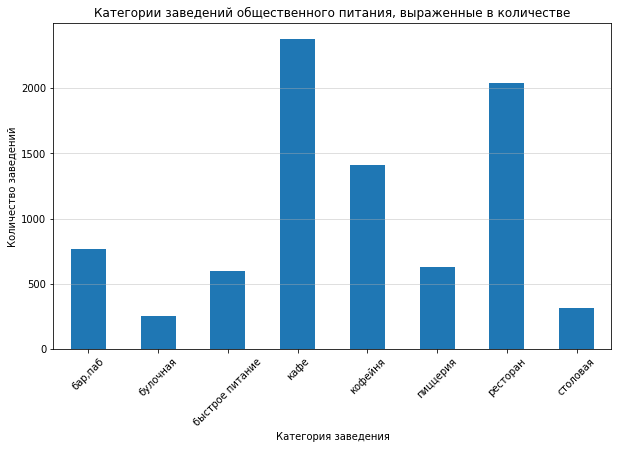

In [31]:
df_agg = df.groupby('category')['name'].count()
df_agg.plot(
    kind='bar',
    title='Категории заведений общественного питания, выраженные в количестве',
    legend=False,
    ylabel='Количество заведений',
    xlabel='Категория заведения',
    rot=45,
    figsize=(10, 6)
)

plt.grid(axis='y', alpha=0.5)


plt.show()

In [32]:
df_agg

category
бар,паб             765
булочная            256
быстрое питание     603
кафе               2378
кофейня            1413
пиццерия            633
ресторан           2043
столовая            315
Name: name, dtype: int64

- Основываясь на данных, можно сказать, что кафе преобладающее количество, их 2378, дальше идут рестораны (2043), кофейни (1413), бар-паб (765), пиццерии (633), а замыкают быстрое питание (603), столовая (315) и булочные (256)
- Данные могут свидетельствовать о том, что такой рынок направлен больше на досуговый формат (количество ресторанов и пабов очень велико)
- Высокая насыщенность кафе создаёт жёсткую конкуренцию, новому игроку потребуется уникальная концепция, чтобы удержаться на этом месте

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

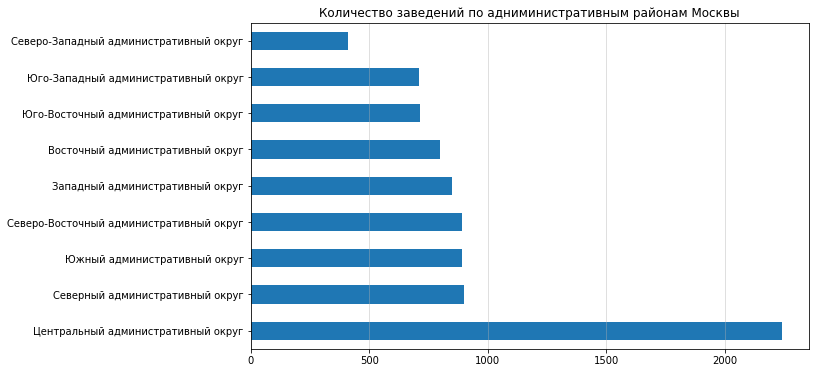

In [65]:
district_counts = df['district'].value_counts()
district_counts.plot(
    kind='barh',
    legend=False,
    figsize=(10, 6),
    title='Количество заведений по адниминистративным районам Москвы',
    ylabel='Количество заведений',
    xlabel=''
)

plt.grid(axis='x', alpha=0.5)

plt.show()

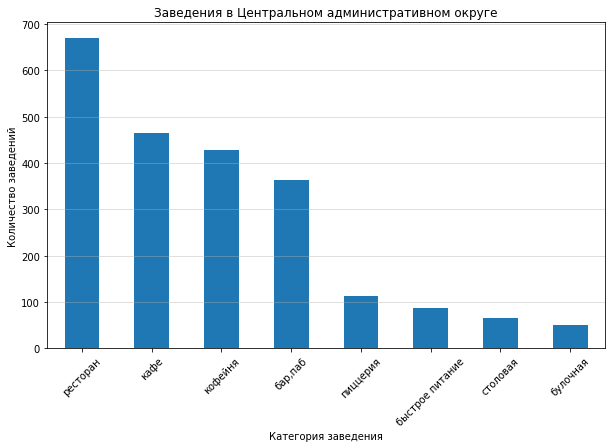

In [34]:
cao_df = df[df['district'] == 'Центральный административный округ']
cao_df = cao_df['category'].value_counts()
cao_df.plot(
    kind='bar',
    legend=False,
    title='Заведения в Центральном административном округе',
    ylabel='Количество заведений',
    xlabel='Категория заведения',
    figsize=(10, 6),
    rot=45
)

plt.grid(axis='y', alpha=0.5)


plt.show()

по графику можно заметить:
- в основном все заведения находятся в ЦАО, скорее всего из\-за того, что большинство крупных офисов и крупных торговых центров находится в центре, что может значить большую выручку для заведений
- также ЦАО более посещаемое место туристами, что может значить больший поток людей, в спальных районах меньший поток туристов
- ЦАО имеет больше развлечений, нежели спальные районы, поэтому поток тоже будет больше именно там
- также в ЦАО преобладает количество ресторанов

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

In [35]:
df['chain'].mean()

0.38127527956221746

In [36]:
chain_to_categories = df.groupby('category')['chain'].mean().sort_values(ascending=False)
chain_to_categories

category
булочная           0.613281
пиццерия           0.521327
кофейня            0.509554
быстрое питание    0.384743
ресторан           0.357318
кафе               0.327586
столовая           0.279365
бар,паб            0.220915
Name: chain, dtype: float64

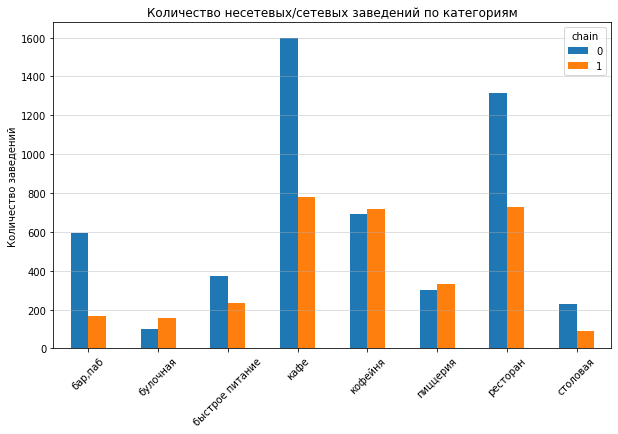

In [37]:
df_categories = df.groupby('category')['chain'].value_counts().unstack()
df_categories.plot(
    kind='bar',
    title='Количество несетевых/сетевых заведений по категориям',
    ylabel='Количество заведений',
    xlabel='',
    figsize=(10,6),
    rot=45
)

plt.grid(axis='y', alpha=0.5)


plt.show()

по данным можно сделать вывод:
- такие категории заведений как булочная (61.3%), пиццерия (52.1%), кофейня (50.9%) являются сетевиками, скорее всего, эти заведения легче стандартизировать, так как человек в основном приходит в эти заведения утолить голод, а не провести досуг
- несетевые заведения, наоборот, представляют из себя более уникальные проекты для того, чтобы убедить клиента пойти именно к ним, а не к конкуренту

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


In [38]:
df['seats'].describe()

count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

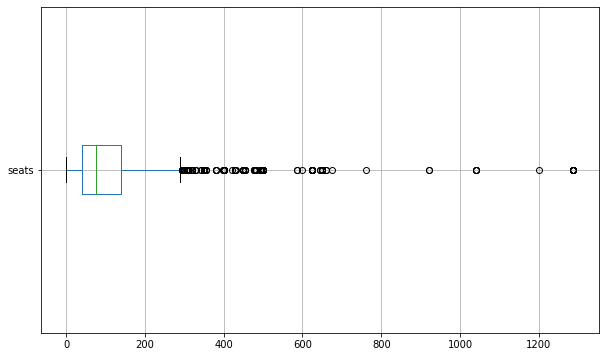

In [39]:
df.boxplot(
    'seats',
    vert=False,
    grid=True,
    figsize=(10,6)
)

plt.show()

In [40]:
df.groupby('category')['seats'].median()

category
бар,паб            82.5
булочная           50.0
быстрое питание    65.0
кафе               60.0
кофейня            80.0
пиццерия           55.0
ресторан           86.0
столовая           75.5
Name: seats, dtype: Float64

по boxplot (ящик с усами) можно заметить, что медиана смещена в левую сторону, что значит о преобладающих больших значениях в данных, то есть присутствует ассиметрия данных.
есть также очень большое количество выбросов и аномальных значений, например, можно заметить, что есть очень большое отклонение от среднего значения, также видим, что есть значение равное 1288, что является ошибкой, скорее всего произошла ошибка при передаче данных или есть места, в которых значение количества мест сильнее отличается от медианы, чем другие, например, банкетные залы, в которых может быть и 300+ мест

средним количеством посадочных мест для всех категорий является 69,

для всех категорий:

бар,паб            82.5

булочная           50.0

быстрое питание    65.0

кафе               60.0

кофейня            80.0

пиццерия           55.0

ресторан           86.0

столовая           75.5

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [41]:
df['rating'].describe()

count    8406.000000
mean        4.229895
std         0.470348
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

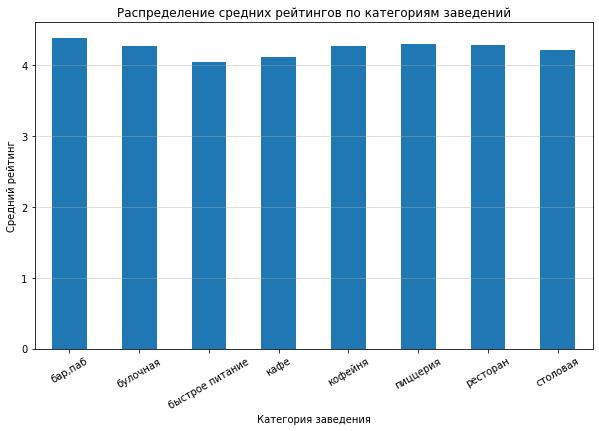

In [42]:
df_rating_mean = df.groupby('category')['rating'].mean()
df_rating_mean.plot(
    kind='bar',
    title='Распределение средних рейтингов по категориям заведений',
    ylabel='Средний рейтинг',
    xlabel='Категория заведения',
    figsize=(10,6),
    rot=30
)

plt.grid(axis='y', alpha=0.5)

plt.show()

основываясь на данных можно сказать:
- самый высокий рейтинг имеет заведения категории "бар,паб", после "ресторан" и "кофейня"
- нет, рейтинги заведений по категориям не сильно разняться друг от друга, все они имеют 4+ рейтинг, но самыми отстающими являются заведения быстрого пиатние, дальше рейтинг разнится на 0.1-0.3

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [43]:
df_corr = df.copy()

In [44]:
df_corr_matrix = df_corr[['category', 'district', 'chain', 'seats', 'price', 'is_24_7', 'rating']].phik_matrix(interval_cols=['chain', 'seats', 'rating'])

In [45]:
data_heatmap = df_corr_matrix.loc[df_corr_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

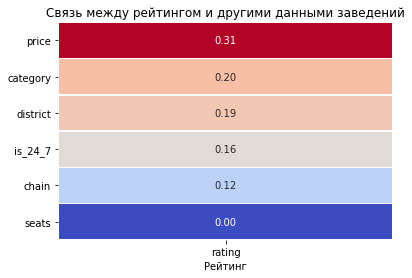

In [46]:
sns.heatmap(
    data_heatmap,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidth=0.5,
    cbar=False
)

plt.title('Связь между рейтингом и другими данными заведений')
plt.xlabel('Рейтинг')

plt.show()

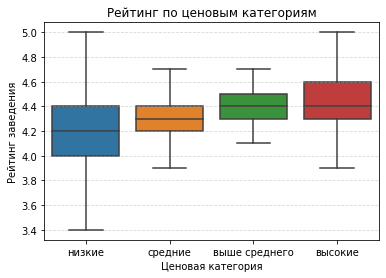

In [47]:
sns.boxplot(
    data=df,
    x='price',
    y='rating',
    order=['низкие', 'средние', 'выше среднего', 'высокие'],
    flierprops=dict(markerfacecolor='red', marker='o'),
    showfliers=False
)

plt.title('Рейтинг по ценовым категориям')
plt.xlabel('Ценовая категория')
plt.ylabel('Рейтинг заведения')
plt.grid(axis='y', linestyle='--', alpha=0.5)


plt.show()

Вывод по проведённой корреляции:
- рейтинг сильнее всего зависит от цены блюд заведения (связь умеренная положительная (0.31))
- также рейтинг зависит и от других показателей: категория заведения (связь слабая положительная (0.20)), расположение заведения (связь слабая положительная (0.19)), от времени работы (слабая положительная (0.16)) и сетевое заведение или нет (связь слабая положительная (0.10))
- рейтинг вообще не зависит от количества мест в нём

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [48]:
stats = df[df['chain'] == 1].groupby('name').agg(
    establishments=('name', 'count'),
    average_rating=('rating', 'mean'),
    categories=('category', 'first')
)

In [49]:
top_15 = stats.sort_values('establishments', ascending=False).head(15).reset_index()

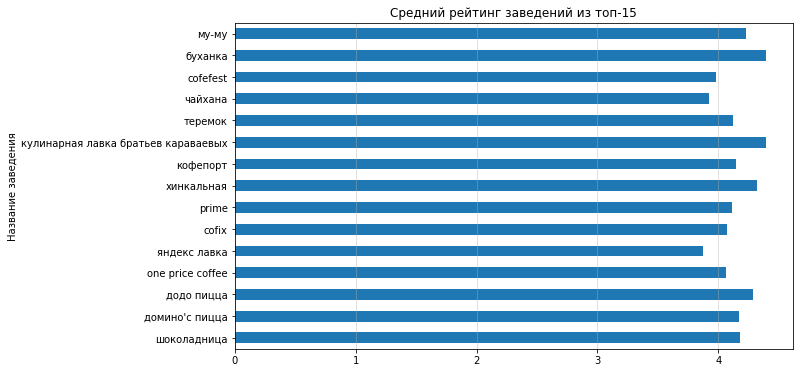

,name,categories,average_rating
0,буханка,булочная,4.40
1,кулинарная лавка братьев караваевых,кафе,4.39
2,хинкальная,быстрое питание,4.32
3,додо пицца,пиццерия,4.29
4,му-му,кафе,4.23
5,шоколадница,кофейня,4.18
6,домино'с пицца,пиццерия,4.17
7,кофепорт,кофейня,4.15
8,теремок,ресторан,4.12
9,prime,ресторан,4.12


In [64]:
top_15.plot(
    kind='barh',
    legend=False,
    x='name',
    y='average_rating',
    title='Средний рейтинг заведений из топ-15',
    ylabel='Средний рейтинг заведений',
    xlabel='Название заведения',
    figsize=(10,6)
)

plt.grid(axis='x', alpha=0.5)

plt.show()

round(top_15.loc[:, ['name', 'categories', 'average_rating']].sort_values(
    by='average_rating', ascending=False), 2
     ).reset_index(drop=True)

по сделанной визуализации можно сделать вывод, что сетевики из топ-15 имеют хороший рейтинг, у всех наблюдается рейтинг больше 4 (кроме чайханы, cofefest и яндекс лавки, как бы комично это ни выглядело), особенно можно отметить заведения буханка, кулинарная лавка братьев караваевых и хинкальную, у них самый высокий рейтинг их заведений, 4.32-4.4

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


In [51]:
median_bill_per_district = df.groupby('district').agg(
    median_bill = ('middle_avg_bill', 'median')
).reset_index()

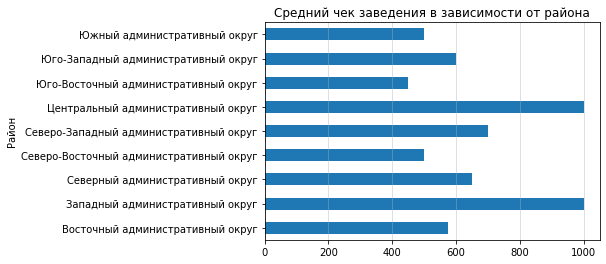

In [63]:
median_bill_per_district.plot(
    kind='barh',
    y='median_bill',
    x='district',
    title='Средний чек заведения в зависимости от района',
    ylabel='Средний чек',
    xlabel='Район',
    legend=False
)

plt.grid(axis='x', alpha=0.5)


plt.show()

In [53]:
median_bill_per_district

,district,median_bill
0,Восточный административный округ,575.0
1,Западный административный округ,1000.0
2,Северный административный округ,650.0
3,Северо-Восточный административный округ,500.0
4,Северо-Западный административный округ,700.0
5,Центральный административный округ,1000.0
6,Юго-Восточный административный округ,450.0
7,Юго-Западный административный округ,600.0
8,Южный административный округ,500.0


визуализация не подтверждает ранее сделанный вывод о том, что ЦАО приносит больше прибыли, на самом деле ЦАО и ЗАО имеют одинаковый средний чек, который равен 1000, но всё равно нельзя судить однозначно, так как мы не знаем про поток людей через эти два округа, будет приносить большую прибыль тот, который имеет больший поток людей, а не больший средний чек

но также эта визуализация подтверждает, чем дальше от центра, тем меньше прибыль, основываясь на среднем чеке, он в среднем меньше чем у ЗАО и ЦАО у других округов в 1.5-2 раза

---


---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

самыми важными выводами являются: определил самый густонаселённый заведениями район, следовательно и конкуренция там самая высокая, также самую популярную категорию заведения и средний чек заведений, на основе которого можно понимать, какие цены больше всего соответствуют району, определил, что есть умеренно положительная связь между средним чеком заведения и их рейтингом, также была определена самая популярная категория заведений и процент сетевиков в них

## 4. Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.

---
1. считаю, что проделанна некая работа, которая определённо поможет с выбором ниши и района под создание своего заведения, но этих данных всё равно мало, ведь нет потока людей в определённых районах, среднего заработка работника и сезонов большого потока людей по категориям, ведь это будут одни из главных критериев выбора своей ниши
2. в основном все заведения находятся в ЦАО, основное количество заведений является ресторанами, из-за чего это создаёт в нише большую конкуренцию, так же можно увидеть, что в принципе у всех категорий примерно одинаковый средний рейтинг, в ЦАО самые большие средние чеки, в отличие от других райнов, также сетевой бизнес сильнее развит в пиццериях, коффейнях и ресторанах, что способствует "борьбе" с большей конкурнцией
3. рекомендовал бы начать с ЗАО, потому что там находится 10.1% заведений Москвы, то есть конкуренция небольшая и средний чек равен 1000₽, что совпадает со значением ЦАО, но конкуренция в ЦАО выше в 2.6 раз (доля заведений Москвы в ЦАО равна 26.6%), лучше всего выбрать кофейню, так как конкуренция не очень большая (17.6% кофейнь в ЗАО)  

(простите что ооооочень много разговорной речи, просто пока не очень знаю, как более хорошо всё расписывать на аналитическом языке)